## 留意事項
* 本資料は教育・情報提供を目的としたものであり、特定の暗号資産・金融商品の売買、投資行動を推奨または勧誘するものではありません。
* 本資料に含まれる見解、分析、シミュレーション等は作成時点の情報および過去データ等に基づくものであり、その正確性・完全性を保証するものではありません。また、将来の成果・価格動向・収益等を保証するものではありません。
* 外部サービス名・製品名の記載は例示であり、主催者またはビットバンク株式会社による推奨、提携、保証を意味するものではありません。

# 2026/06 イベント資料：先物乖離demean戦略
## botter会 先物乖離編

### demeanで「アルトの先物過熱」は取れるのか？

> **対象**: 裁量取引の経験をベースに、AIやPythonでボット検証を始めたい方  
> **今回の宿題**: ほへと先生から「demeanを使った先物乖離戦略を試してみて」

![botterkai](botterkai.jpeg)

---
## はじめに

### botter会とは
* 目的：botterを続けるためのきっかけつくり
* 概要：ひとりでボットを作ろうとすると、アイデア出し → データ取得 → 実装 → 検証 → 振り返り、どこかで止まりがちです。この会では毎回テーマを決めて、実際に手を動かした結果をほへと先生に見せてフィードバックをもらいながら続ける仕組みを作っています。どなたでも質問歓迎です。

### この資料の流れ

| Step | 内容 | ひとことで |
|---|---|---|
| 1 | 用語を確認する | basis・demean・rank・score など |
| 2 | 基本ロジックを確認する | demean上位ショート・下位ロング |
| 3 | demeanのみで検証する | 純粋demeanロングショートは弱い |
| 4 | ret1確認条件を足す | 純粋demeanLS vs ret1確認つきscore LS |
| 5 | ロング vs ショートを比較する | ret1確認つきscoreではショート側が良い |
| 6 | 地合いフィルターを探す | SOL/BTC弱い局面に絞る |
| 7 | コスト耐性を確認する | 現実的なコストでも残るか（funding込み） |
| 8 | 10/10清算イベント以降の仮説 | なぜ最近効いて見えるのか |
| 9 | まとめ & 次やること | A0ロジックとフォワード方針 |

---
## Step 1: 用語を確認する

In [ ]:
from pathlib import Path

# GitHub配布時に、Jupyterをリポジトリ直下・basis_kasetsu内のどちらで起動しても動くようにする。
def find_data_dir(start: Path = Path.cwd()) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    required = "attack_short_with_regime.csv"
    for p in candidates:
        if (p / "data_for_notebook" / required).exists():
            return p / "data_for_notebook"
        if (p / "basis_kasetsu" / "data_for_notebook" / required).exists():
            return p / "basis_kasetsu" / "data_for_notebook"
    raise FileNotFoundError(
        "data_for_notebook が見つかりません。GitHubからCSV込みでcloneし、"
        "リポジトリ直下または basis_kasetsu 内でノートブックを実行してください。"
    )

DATA_DIR = find_data_dir()
print(f"DATA_DIR = {DATA_DIR}")


In [2]:
import pandas as pd

glossary = pd.DataFrame([
    {"用語": "basis（先物乖離）",      "意味": "(先物終値 − 現物終値) ÷ 現物終値",      "補足": "＋なら先物が割高＝強気のサイン"},
    {"用語": "demean",                "意味": "basis から当該銘柄の平均乖離を引いた値",  "補足": "平均期間Nはパラメータ。普段より先物がどれだけ過熱しているかを見る"},
    {"用語": "ret1",                  "意味": "前日先物リターン",                    "補足": "future_close[t] / future_close[t-1] − 1"},
    {"用語": "rank",                  "意味": "同じ日の銘柄内での順位",              "補足": "銘柄間で比較しやすくするために使う"},
    {"用語": "score",                 "意味": "銘柄を選ぶための並び替え用の点数",      "補足": "A0ではdemean_rankとret1_rankを合成"},
    {"用語": "zscore（Zスコア）",      "意味": "(basis − 平均) ÷ 標準偏差",             "補足": "スパイクの強さが標準偏差で均される"},
    {"用語": "bps（ベーシスポイント）", "意味": "1 bps = 0.01%",                        "補足": "60 bps/day ≈ 日次 +0.60%"},
    {"用語": "Sharpe比",              "意味": "平均リターン ÷ 標準偏差（年率換算）",     "補足": "1.0 以上が一般的な目安"},
    {"用語": "MAE",                   "意味": "Maximum Adverse Excursion",             "補足": "保有中の最大含み損。荒い銘柄ほど大きい"},
    {"用語": "フォワードテスト",       "意味": "リアルタイムでシグナルを毎日記録",        "補足": "バックテストが実際に機能するかを確認する工程"},
])
glossary.set_index("用語")

,意味,補足
用語,,
basis（先物乖離）,(先物終値 − 現物終値) ÷ 現物終値,＋なら先物が割高＝強気のサイン
demean,basis から当該銘柄の平均乖離を引いた値,平均期間Nはパラメータ。普段より先物がどれだけ過熱しているかを見る
ret1,前日先物リターン,future_close[t] / future_close[t-1] − 1
rank,同じ日の銘柄内での順位,銘柄間で比較しやすくするために使う
score,銘柄を選ぶための並び替え用の点数,A0ではdemean_rankとret1_rankを合成
zscore（Zスコア）,(basis − 平均) ÷ 標準偏差,スパイクの強さが標準偏差で均される
bps（ベーシスポイント）,1 bps = 0.01%,60 bps/day ≈ 日次 +0.60%
Sharpe比,平均リターン ÷ 標準偏差（年率換算）,1.0 以上が一般的な目安
MAE,Maximum Adverse Excursion,保有中の最大含み損。荒い銘柄ほど大きい


---
## Step 2: 基本ロジック

前回は、先物乖離のクロスセクション戦略を **Zスコア** で検証しました。  
その時に、ほへと先生から以下の指摘がありました。

### ほへと先生のコメント

> **Zスコアは標準偏差で割るので、乖離の絶対的な大きさが消えてしまう。**  
> 「先物がどれだけ激しく過熱したか」を見るなら、  
> 標準偏差で割らずに **平均だけ引く（demean）** の方が使えるかもしれない。

### 今回見たいもの

> **その銘柄にとって、普段よりどれくらい先物側が過熱しているか**

これを見るために、`demean_N` を使います。  
`N` は平均を取る期間で、固定ではありません。

### 出発点の基本ロジック

過去のクロスセクション検証と同じ考え方で、まずはロングショートで確認します。

```text
basis     = (future_close - spot_close) / spot_close
demean_N  = basis - N期間平均basis

同じ日の銘柄を横断比較する
上位2銘柄: 先物側が普段より過熱している → ショート
下位2銘柄: 先物側が普段より冷えている → ロング
日次損益 : (ショート側 + ロング側) / 2
```

まず **demeanだけの基本形** が機能するかを確認します。

In [3]:
import pandas as pd

# zscore と demean の違い
comparison = pd.DataFrame([
    {
        "指標":   "zscore_N",
        "計算式": "(basis − N期間平均) ÷ N期間標準偏差",
        "スケール": "標準化される",
        "注意点":  "乖離幅は標準偏差で均される",
    },
    {
        "指標":   "demean_N",
        "計算式": "basis − N期間平均",
        "スケール": "乖離幅が残る",
        "注意点":  "Nは固定ではない。Step 3で候補を比較する",
    },
])
comparison.set_index("指標")

,計算式,スケール,注意点
指標,,,
zscore_N,(basis − N期間平均) ÷ N期間標準偏差,標準化される,乖離幅は標準偏差で均される
demean_N,basis − N期間平均,乖離幅が残る,Nは固定ではない。Step 3で候補を比較する


---
## Step 3: demeanとは

まずは余計な条件を入れず、**demeanだけのロングショート** を検証します。

```text
シグナル: t日のclose時点で計算
約定    : t+1日のopenでエントリー → t+1日のcloseでクローズ
demean_N = basis[t] - mean(basis[t-N:t-1])
ショート: demean_N が高い上位2銘柄
ロング  : demean_N が低い下位2銘柄
日次損益: (ショート側 + ロング側) / 2
条件    : 地合いフィルターなし
コスト  : 往復8bps
```

ここでは `N = 7, 14, 21, 28, 60日` を候補にして、どの窓がよさそうかを確認します。

**注意**: 小型アルトには日次±50%超の急変動が含まれます。品質チェック上のCRITICALは急変動由来のみですが、この段階の結果は外れ値に敏感です。


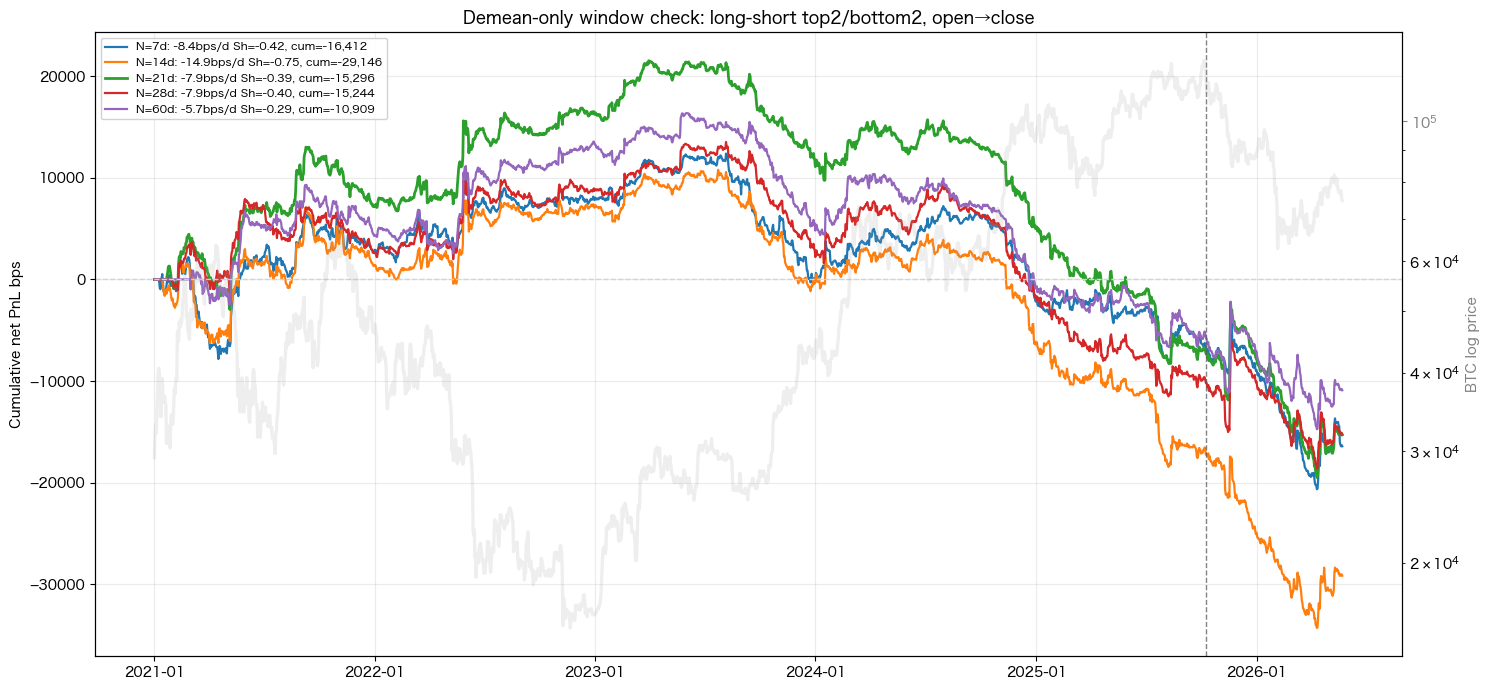

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

# --- demeanのみ・フィルターなしのロングショート窓候補比較（open→close） ---
daily = pd.read_csv(DATA_DIR / "open_close_demean_only_window_daily.csv", parse_dates=["date"])
summary = pd.read_csv(DATA_DIR / "open_close_demean_only_window_summary.csv")
regime = pd.read_csv(DATA_DIR / "btc_eth_sol_regime_daily.csv", parse_dates=["date"])

ls_summary = (summary[summary["side"] == "long_short"]
              .sort_values("window")
              .set_index("window"))
windows = ls_summary.index.tolist()
all_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
btc = regime.set_index("date").reindex(all_dates)["BTC"]

fig, ax = plt.subplots(figsize=(15, 7))
ax_btc = ax.twinx()
ax_btc.plot(btc.index, btc, color="0.65", lw=2.4, alpha=0.18)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log price", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for window, color in zip(windows, colors):
    window_daily = (daily[daily["window"] == window]
                    .set_index("date")
                    .reindex(all_dates))
    net = window_daily["long_short_net_bps"].fillna(0.0)
    metrics = ls_summary.loc[window]
    ax.plot(
        all_dates,
        net.cumsum(),
        color=color,
        lw=2.0 if window == 21 else 1.6,
        label=(
            f"N={window}d: {metrics['active_mean_bps']:.1f}bps/d "
            f"Sh={metrics['active_sharpe']:.2f}, cum={metrics['cum_net_bps']:,.0f}"
        ),
    )

ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)
ax.set_title("Demean-only window check: long-short top2/bottom2, open→close")
ax.set_ylabel("Cumulative net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

summary = pd.read_csv(DATA_DIR / "open_close_demean_only_window_summary.csv")
summary_ls = summary[summary["side"] == "long_short"].copy()

result = pd.DataFrame({
    "N（日）": summary_ls["window"],
    "bps/day": summary_ls["active_mean_bps"].round(1),
    "Sharpe": summary_ls["active_sharpe"].round(2),
    "累積bps": summary_ls["cum_net_bps"].round(0).astype(int),
    "最大DD bps": summary_ls["maxdd_bps"].round(0).astype(int),
    "勝率": (summary_ls["win_rate_active"] * 100).round(1).astype(str) + "%",
    "取引日数": summary_ls["active_days"].astype(int),
})
result.sort_values("N（日）").set_index("N（日）")


,bps/day,Sharpe,累積bps,最大DD bps,勝率,取引日数
N（日）,,,,,,
7,-8.4,-0.42,-16412,-33021,48.0%,1962
14,-14.9,-0.75,-29146,-45059,47.4%,1955
21,-7.9,-0.39,-15296,-41005,47.2%,1948
28,-7.9,-0.40,-15244,-32146,47.5%,1941
60,-5.7,-0.29,-10909,-31101,45.9%,1909


### 読み取り

- `demean` の窓は固定ではなく、`N` を変えて検証するパラメータです。
- `open→close` で見ても、フィルターなし・demean単独のロングショートはどの窓でも安定していません。
- つまり、**基本形のまま翌日の日中でロングショートするだけでは弱い** です。

次に、純粋な `demean_21d` ロングショートと、`ret1` 確認つきscoreのロングショートを比較します。  
ここがA0候補の肝です。


---
## Step 4: 前日先物パンプロジック

Step 3では、demeanだけの基本形が弱いことを確認しました。

`demean` は「先物乖離が普段より高い銘柄」を拾えます。  
ただし、それだけだと **単に乖離が高いだけの銘柄** も混ざります。

今回ロングショートで狙いたいのは短期的に過熱した銘柄です。  
そこで、前日先物リターン `ret1` を少し混ぜて、**直前に上がったか** を確認します。

仮説はシンプルです。

> **前日にパンプしたアルトは翌日の日中に続かず平均回帰しやすいのではないか**

```text
ret1  = future_close[t] / future_close[t-1] - 1
score = 0.70 × demean_rank + 0.30 × ret1_rank

シグナル: t日のclose時点
約定    : t+1日のopen → t+1日のclose
```

- `demean_rank`: 先物が現物に対して、普段よりどれだけ過熱しているか
- `ret1_rank`: 前日に先物価格がどれだけ上がったか

ここでは、前段と同じく **ロングショート** で比較します。  
つまり、**純粋demeanロングショート** と **ret1確認つきscoreロングショート** を同じ `open→close + 往復8bps` で比べます。


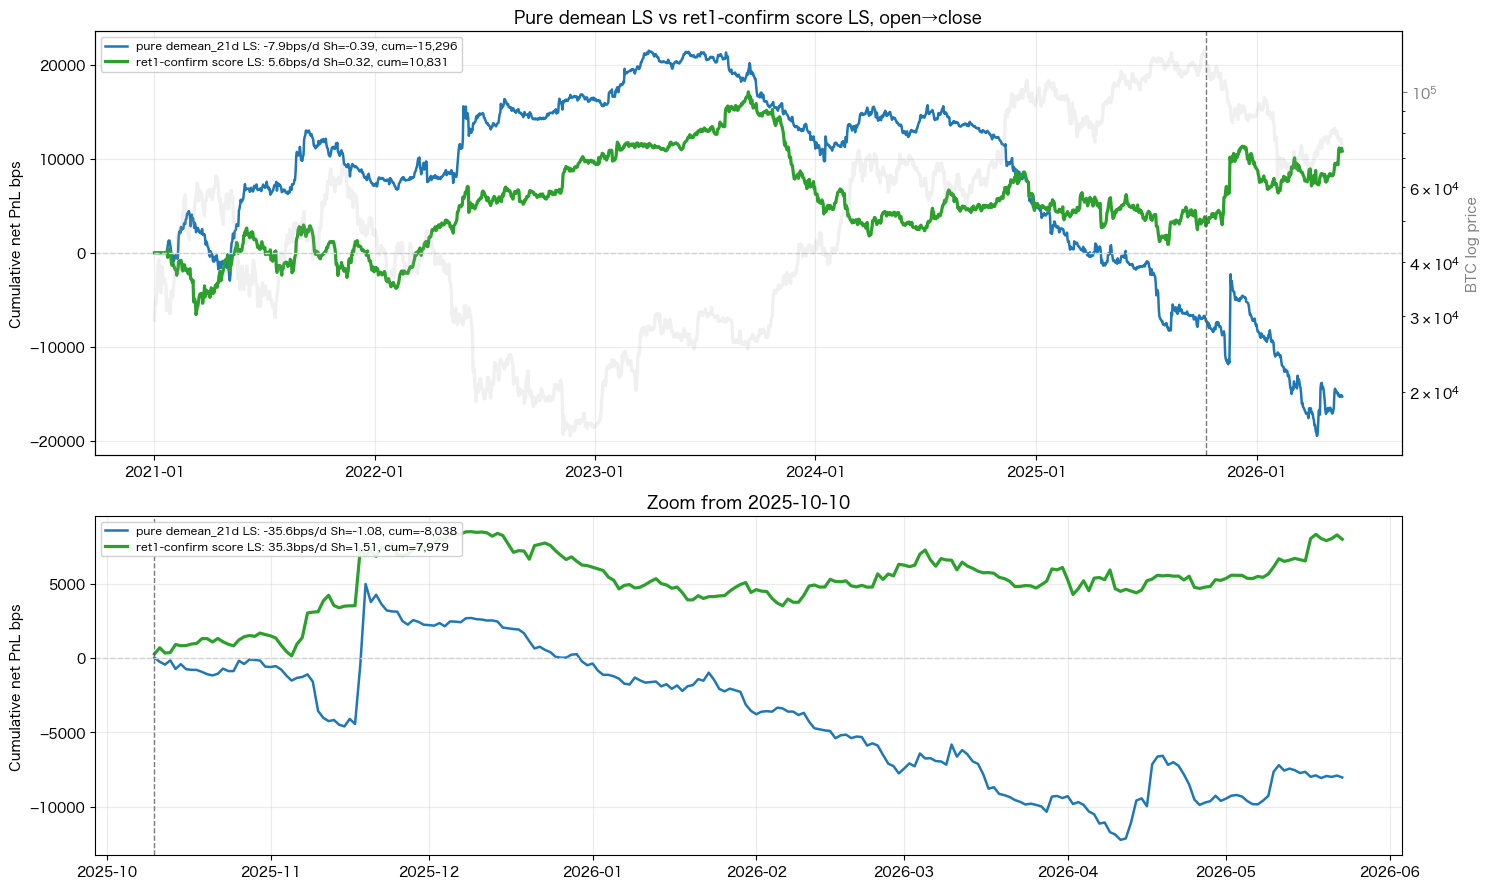

In [6]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

# --- 純粋demeanロングショート vs ret1確認つきscoreロングショート（open→close） ---
comparison = pd.read_csv(DATA_DIR / "open_close_pure_vs_ret1_confirm_ls_daily.csv", parse_dates=["date"])
regime = pd.read_csv(DATA_DIR / "btc_eth_sol_regime_daily.csv", parse_dates=["date"])

all_dates = pd.date_range(comparison["date"].min(), comparison["date"].max(), freq="D")
plot_df = comparison.set_index("date").reindex(all_dates)
btc = regime.set_index("date").reindex(all_dates)["BTC"]

START_EVENT = pd.Timestamp("2025-10-10")

def sharpe_val(values):
    values = values.dropna()
    if len(values) < 2 or values.std(ddof=1) == 0:
        return np.nan
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

def label_for(frame, value_col, active_col, label):
    active = frame.loc[frame[active_col].fillna(False), value_col].dropna()
    return f"{label}: {active.mean():.1f}bps/d Sh={sharpe_val(active):.2f}, cum={active.sum():,.0f}"

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False,
                         gridspec_kw={"height_ratios": [1.25, 1]})

# 全期間
ax = axes[0]
ax_btc = ax.twinx()
ax_btc.plot(btc.index, btc, color="0.65", lw=2.4, alpha=0.16)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log price", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

for value_col, active_col, label, color, line_width in [
    ("pure_demean_21d_ls", "is_active_pure", "pure demean_21d LS", "#1f77b4", 1.8),
    ("ret1_confirm_score_ls", "is_active_ret1_confirm", "ret1-confirm score LS", "#2ca02c", 2.3),
]:
    ax.plot(
        plot_df.index,
        plot_df[value_col].fillna(0).cumsum(),
        color=color,
        lw=line_width,
        label=label_for(plot_df, value_col, active_col, label),
    )

ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(START_EVENT, color="0.35", ls="--", lw=1, alpha=0.8)
ax.set_title("Pure demean LS vs ret1-confirm score LS, open→close")
ax.set_ylabel("Cumulative net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# 10/10以降ズーム
ax = axes[1]
zoom = plot_df[plot_df.index >= START_EVENT].copy()
for value_col, active_col, label, color, line_width in [
    ("pure_demean_21d_ls", "is_active_pure", "pure demean_21d LS", "#1f77b4", 1.8),
    ("ret1_confirm_score_ls", "is_active_ret1_confirm", "ret1-confirm score LS", "#2ca02c", 2.3),
]:
    ax.plot(
        zoom.index,
        zoom[value_col].fillna(0).cumsum(),
        color=color,
        lw=line_width,
        label=label_for(zoom, value_col, active_col, label),
    )

ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(START_EVENT, color="0.35", ls="--", lw=1, alpha=0.8)
ax.set_title("Zoom from 2025-10-10")
ax.set_ylabel("Cumulative net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

summary = pd.read_csv(DATA_DIR / "open_close_pure_vs_ret1_confirm_ls_summary.csv")

result = pd.DataFrame({
    "期間": summary["期間"],
    "戦略": summary["戦略"],
    "bps/day": summary["active_mean_bps"].round(1),
    "Sharpe": summary["active_sharpe"].round(2),
    "累積bps": summary["cum_net_bps"].round(0).astype(int),
    "最大DD bps": summary["maxdd_bps"].round(0).astype(int),
    "勝率": (summary["win_rate_active"] * 100).round(1).astype(str) + "%",
    "取引日数": summary["active_days"].astype(int),
})
result.set_index(["期間", "戦略"])


bps/day  Sharpe  累積bps  最大DD bps     勝率  取引日数
期間      戦略                                                                 
全期間     純粋demean_21dロングショート      -7.9   -0.39 -15296    -41005  47.2%  1948
        ret1確認つきscoreロングショート      5.6    0.32  10831    -16243  53.2%  1948
2025年〜  純粋demean_21dロングショート     -39.9   -1.54 -20284    -24660  39.4%   508
        ret1確認つきscoreロングショート     11.2    0.55   5667     -5507  53.3%   508
10/10以降 純粋demean_21dロングショート     -35.6   -1.08  -8038    -17207  36.7%   226
        ret1確認つきscoreロングショート     35.3    1.51   7979     -4981  50.9%   226

### 読み取り

`open→close` で見ても、純粋な `demean_21d` ロングショートより、`ret1` 確認つきscoreのロングショートの方が改善しました。

ただし、この時点ではまだ **ロングとショートを混ぜた結果** です。  
scoreが良く見える理由が、ロング側なのかショート側なのかはまだ分かりません。

ここで言えることは、A0候補の肝として、

> **demeanで先物過熱を見たうえで、ret1で前日先物パンプを確認すること**

が効いていそう、ということです。

次に、この `ret1` 確認つきscoreをロング側・ショート側に分解します。


---
## Step 5: ロング vs ショート

Step 4で、純粋demeanロングショートより `ret1` 確認つきscoreのロングショートの方が良さそうだと確認しました。

次に、この **A0候補スコア** で、ロング側とショート側のどちらが取れているかを見ます。  
ここではまだ地合いフィルターは入れません。

```text
score = 0.70 × demean_rank + 0.30 × ret1_rank
約定  = t+1日のopen → t+1日のclose
```

- **ショート**: score 上位2銘柄をショート
- **ロング**:  score 下位2銘柄をロング

この比較で、A0をショート専用に寄せるべきかを判断します。


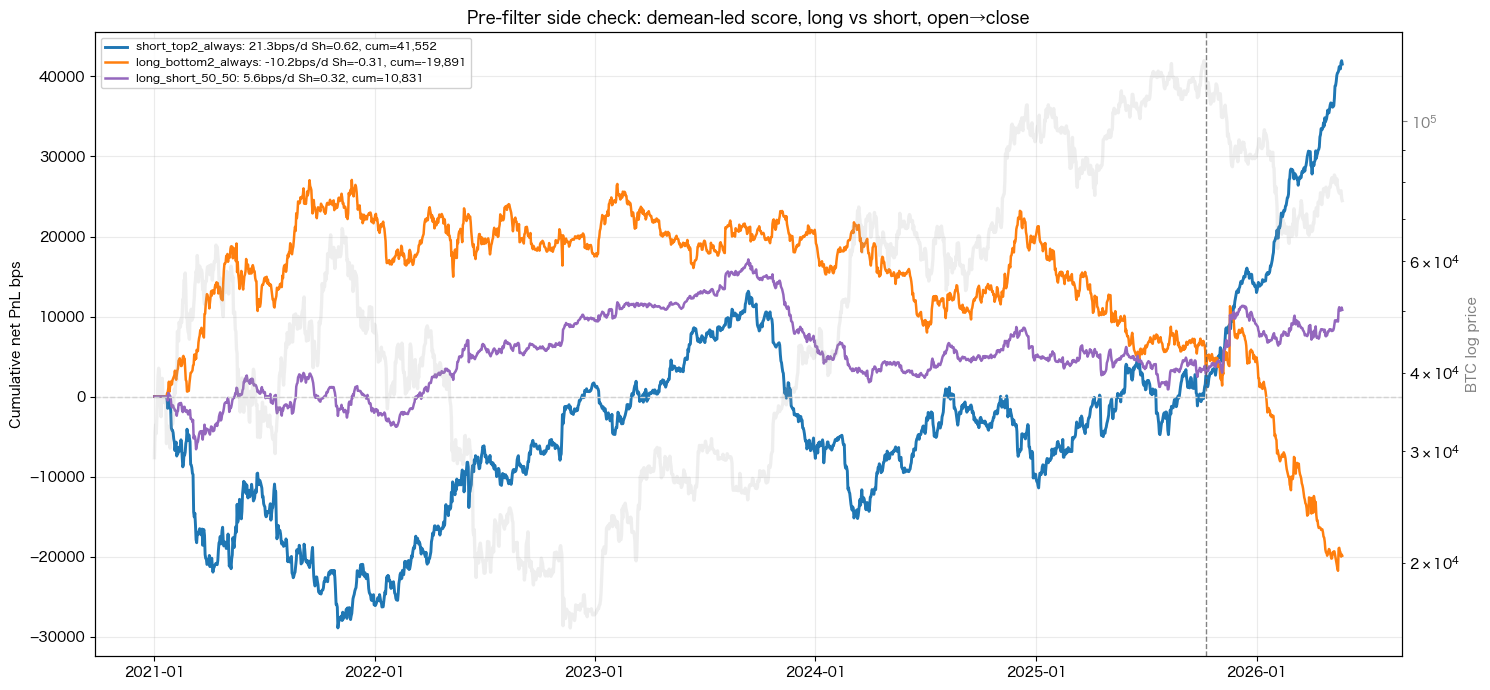

In [8]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

# --- フィルターなしで、ショート側とロング側を比較（open→close） ---
regime = pd.read_csv(DATA_DIR / "btc_eth_sol_regime_daily.csv", parse_dates=["date"])
side_daily = pd.read_csv(DATA_DIR / "open_close_side_daily.csv", parse_dates=["date"])

side_daily["short_cum"] = side_daily["short_net_bps"].fillna(0.0).cumsum()
side_daily["long_cum"] = side_daily["long_net_bps"].fillna(0.0).cumsum()
side_daily["long_short_cum"] = side_daily["long_short_net_bps"].fillna(0.0).cumsum()
side_daily["long_short_active"] = side_daily["short_active"].fillna(False) & side_daily["long_active"].fillna(False)

def sharpe_val(values):
    values = values.dropna()
    if len(values) < 2 or values.std(ddof=1) == 0:
        return np.nan
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

all_dates = pd.date_range(side_daily["date"].min(), side_daily["date"].max(), freq="D")
btc = regime.set_index("date").reindex(all_dates)["BTC"]

curves = [
    ("short_top2_always", "short_net_bps", "short_active", "short_cum", "#1f77b4", 2.1),
    ("long_bottom2_always", "long_net_bps", "long_active", "long_cum", "#ff7f0e", 1.8),
    ("long_short_50_50", "long_short_net_bps", "long_short_active", "long_short_cum", "#9467bd", 1.8),
]

fig, ax = plt.subplots(figsize=(15, 7))
ax_btc = ax.twinx()
ax_btc.plot(btc.index, btc, color="0.65", lw=2.4, alpha=0.18)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log price", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

for name, value_col, active_col, cumulative_col, color, line_width in curves:
    active = side_daily.loc[side_daily[active_col].fillna(False), value_col]
    ax.plot(
        side_daily["date"],
        side_daily[cumulative_col],
        color=color,
        lw=line_width,
        label=f"{name}: {active.mean():.1f}bps/d Sh={sharpe_val(active):.2f}, cum={active.sum():,.0f}",
    )

ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)
ax.set_title("Pre-filter side check: demean-led score, long vs short, open→close")
ax.set_ylabel("Cumulative net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

summary = pd.read_csv(DATA_DIR / "open_close_side_summary.csv")
selected = summary[summary["期間"].isin(["全期間", "2025年〜", "10/10以降"])].copy()

result = pd.DataFrame({
    "方向": selected["方向"],
    "期間": selected["期間"],
    "bps/day": selected["active_mean_bps"].round(1),
    "Sharpe": selected["active_sharpe"].round(2),
    "累積bps": selected["cum_net_bps"].round(0).astype(int),
    "最大DD bps": selected["maxdd_bps"].round(0).astype(int),
    "勝率": (selected["win_rate_active"] * 100).round(1).astype(str) + "%",
    "取引日数": selected["active_days"].astype(int),
})
result.set_index(["方向", "期間"])


,,bps/day,Sharpe,累積bps,最大DD bps,勝率,取引日数
方向,期間,,,,,,
ショート上位2（フィルターなし）,全期間,21.3,0.62,41552,-28909,54.6%,1948
ロング下位2（フィルターなし）,全期間,-10.2,-0.31,-19891,-48842,49.2%,1948
ロングショート同額（参考）,全期間,5.6,0.32,10831,-16243,53.2%,1948
ショート上位2（フィルターなし）,2025年〜,100.9,3.29,51255,-9337,61.0%,508
ロング下位2（フィルターなし）,2025年〜,-78.6,-2.16,-39921,-43058,41.5%,508
ロングショート同額（参考）,2025年〜,11.2,0.55,5667,-5507,53.3%,508
ショート上位2（フィルターなし）,10/10以降,172.3,6.67,38940,-3050,67.7%,226
ロング下位2（フィルターなし）,10/10以降,-101.7,-2.31,-22981,-33059,35.0%,226
ロングショート同額（参考）,10/10以降,35.3,1.51,7979,-4981,50.9%,226


### 解釈

`open→close` でも、A0候補スコアはロングよりショート側の方が筋が良さそうです。

**ロング側が機能しにくい仮説：**  
アルトが弱い局面では、売られた銘柄がそのままさらに売られることがあります。  
「売られすぎだから買う」は、相場の流れに逆らいやすいです。

**ショート側が機能する仮説：**  
先物主導で急騰したパンプは、翌日の日中に買いが続かなければフェードします。  
この「パンプ後の戻り」を取るなら、ロング反転よりショート側を本線にした方が自然です。

ただし、常時ショートでは相場全体が強い時に負けます。  
次に、**ショートを打つ地合い** を絞ります。


---
## Step 6: 地合いフィルター（ドミナンス）

Step 5で、A0候補スコアはロングよりショート側に寄せる方がよさそうだと見ました。  
ただし、アルト全体が強い時に常時ショートすると、パンプが続いて踏み上げられます。

ここで見たいのは、**アルトにお金が入ってきていない冷え相場** です。  
ライト層の加熱感がなく、個別アルトのパンプが続きにくい状態、と仮定します。

そのproxyとして、代表的なアルト/BTCペアを比較しました。  
それぞれについて `各アルト/BTC < 180日移動平均` の時だけショート戦略を動かし、`open→close + 往復8bps` で成績を確認します。


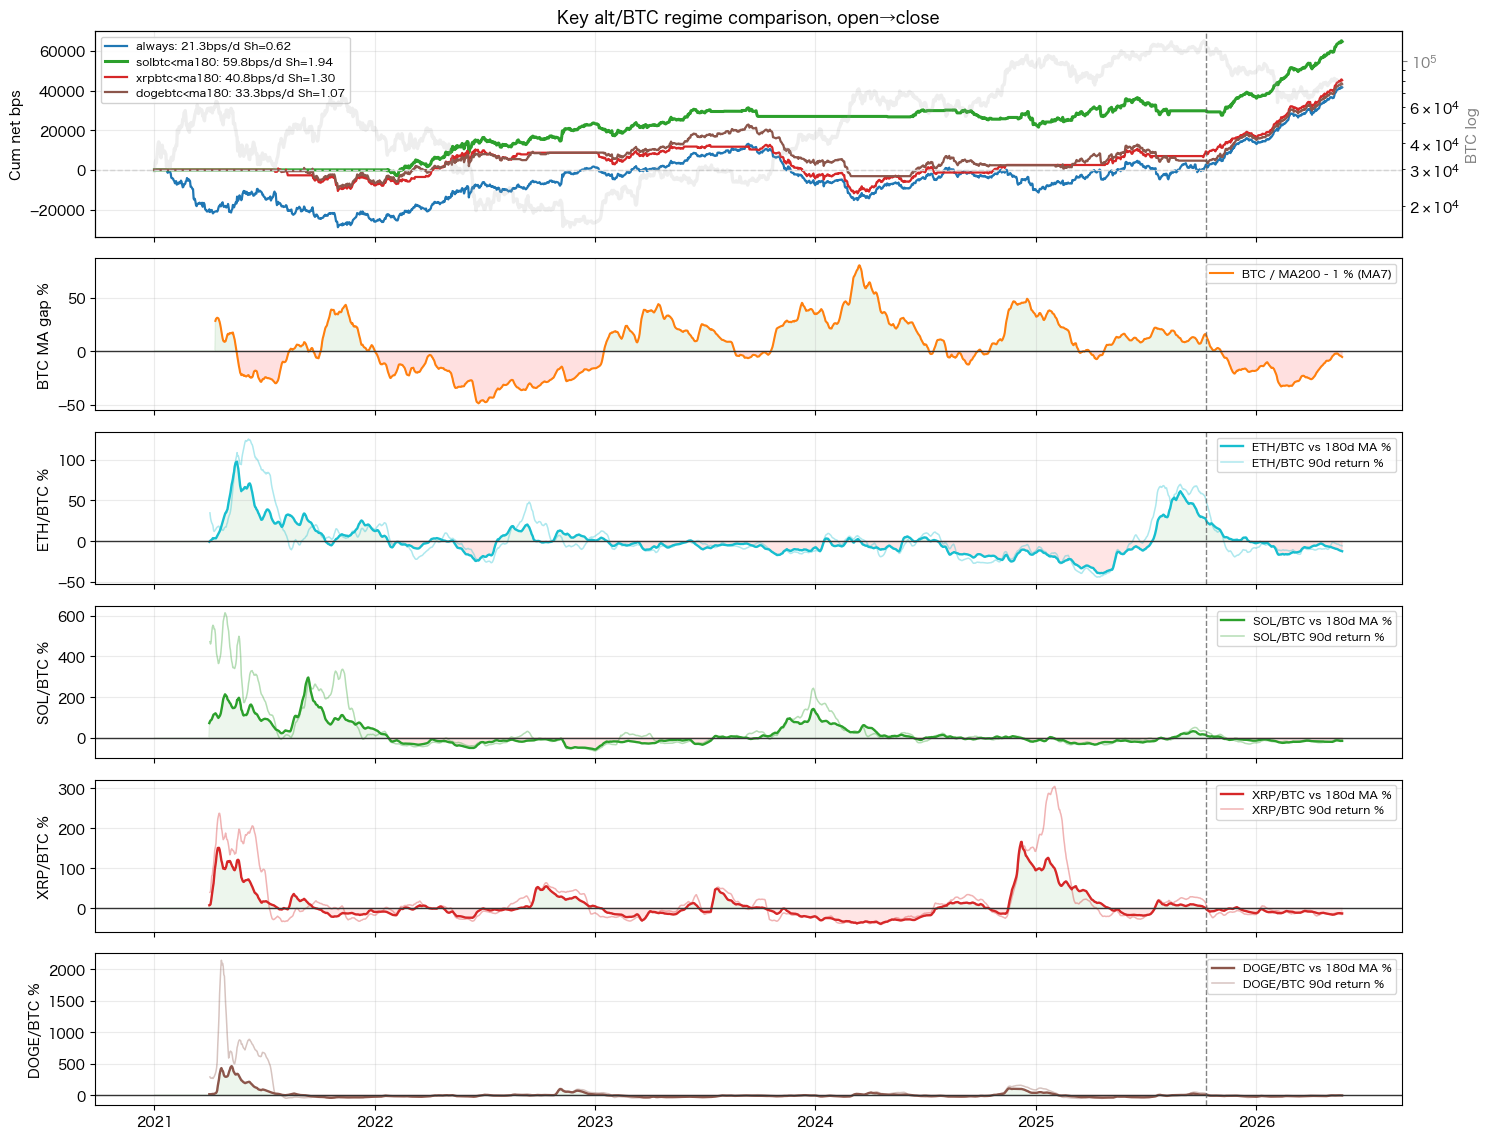

In [10]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

# --- 代表アルト/BTCフィルター比較（open→close） ---
regime = pd.read_csv(DATA_DIR / "representative_altbtc_regime_daily.csv", parse_dates=["date"])

curve_files = {
    "always": DATA_DIR / "open_close_daily_short_top2_always.csv",
    "solbtc<ma180": DATA_DIR / "open_close_daily_short_top2_solbtc_down.csv",
    "xrpbtc<ma180": DATA_DIR / "open_close_daily_short_top2_xrpbtc_down.csv",
    "dogebtc<ma180": DATA_DIR / "open_close_daily_short_top2_dogebtc_down.csv",
}
curves = {name: pd.read_csv(path, parse_dates=["date"]) for name, path in curve_files.items()}
colors = {
    "always": "#1f77b4",
    "solbtc<ma180": "#2ca02c",
    "xrpbtc<ma180": "#d62728",
    "dogebtc<ma180": "#8c564b",
}

def sharpe_val(values):
    values = values.dropna()
    if len(values) < 2 or values.std(ddof=1) == 0:
        return np.nan
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

# --- 描画（6パネル構成） ---
KEY_ASSETS = ["ETH", "SOL", "XRP", "DOGE"]
fig, axes = plt.subplots(
    len(KEY_ASSETS) + 2, 1, figsize=(15, 11.5), sharex=True,
    gridspec_kw={"height_ratios": [1.35, 1, 1, 1, 1, 1]}
)

# 上段：戦略別累積bps比較
ax = axes[0]
all_dates = pd.date_range(regime["date"].min(), regime["date"].max(), freq="D")
btc = regime.set_index("date").reindex(all_dates)["BTC"]
for name in ["always", "solbtc<ma180", "xrpbtc<ma180", "dogebtc<ma180"]:
    curve = curves[name].copy()
    active = curve.loc[curve["is_active"], "net_bps"]
    ax.plot(
        curve["date"],
        curve["net_bps"].fillna(0.0).cumsum(),
        label=f"{name}: {active.mean():.1f}bps/d Sh={sharpe_val(active):.2f}",
        color=colors[name],
        lw=2.2 if name == "solbtc<ma180" else 1.6,
    )
ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)
ax.set_title("Key alt/BTC regime comparison, open→close")
ax.set_ylabel("Cum net bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax_btc = ax.twinx()
ax_btc.plot(btc.index, btc, color="0.65", lw=2.4, alpha=0.18)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

# BTC MA200ギャップパネル
ax = axes[1]
btc_gap = regime["btc_ma200_gap_ma7"] * 100
ax.plot(regime["date"], btc_gap, color="#ff7f0e", label="BTC / MA200 - 1 % (MA7)")
ax.axhline(0, color="0.2", lw=1)
ax.fill_between(regime["date"], 0, btc_gap.fillna(0),
                where=btc_gap.fillna(0) < 0, color="red", alpha=0.12)
ax.fill_between(regime["date"], 0, btc_gap.fillna(0),
                where=btc_gap.fillna(0) >= 0, color="green", alpha=0.08)
ax.set_ylabel("BTC MA gap %")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)

# アルト/BTC各パネル（gap_ma7 + ret90_ma7）
alt_colors = {"ETH": "#17becf", "SOL": "#2ca02c", "XRP": "#d62728", "DOGE": "#8c564b"}
for axis_index, asset in enumerate(KEY_ASSETS, start=2):
    asset_key = asset.lower()
    gap = regime[f"{asset_key}btc_gap_ma7"] * 100
    ret90 = regime[f"{asset_key}btc_ret90_ma7"] * 100
    color = alt_colors[asset]
    ax = axes[axis_index]
    ax.plot(regime["date"], gap, color=color, lw=1.7, label=f"{asset}/BTC vs 180d MA %")
    ax.plot(regime["date"], ret90, color=color, lw=1.1, alpha=0.35, label=f"{asset}/BTC 90d return %")
    ax.axhline(0, color="0.2", lw=1)
    ax.fill_between(regime["date"], 0, gap.fillna(0),
                    where=gap.fillna(0) < 0, color="red", alpha=0.10)
    ax.fill_between(regime["date"], 0, gap.fillna(0),
                    where=gap.fillna(0) >= 0, color="green", alpha=0.07)
    ax.set_ylabel(f"{asset}/BTC %")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="upper right")
    ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
from IPython.display import display, Markdown

summary = pd.read_csv(DATA_DIR / "open_close_regime_filter_summary.csv")

full = summary[summary["期間"] == "全期間"].copy()
full_table = pd.DataFrame({
    "フィルター": full["フィルター"],
    "稼働日bps/day": full["active_mean_bps"].round(1),
    "稼働日Sharpe": full["active_sharpe"].round(2),
    "暦日bps/day": full["calendar_mean_bps"].round(1),
    "累積bps": full["cum_net_bps"].round(0).astype(int),
    "最大DD bps": full["maxdd_bps"].round(0).astype(int),
    "稼働日数": full["active_days"].astype(int),
})

post = summary[
    (summary["期間"] == "10/10以降")
    & (summary["フィルター"].isin(["制御なし（常時）", "SOL/BTC  < MA180 ✅"]))
].copy()
post_table = pd.DataFrame({
    "フィルター": post["フィルター"],
    "稼働日bps/day": post["active_mean_bps"].round(1),
    "稼働日Sharpe": post["active_sharpe"].round(2),
    "暦日bps/day": post["calendar_mean_bps"].round(1),
    "累積bps": post["cum_net_bps"].round(0).astype(int),
    "最大DD bps": post["maxdd_bps"].round(0).astype(int),
    "稼働日数": post["active_days"].astype(int),
})

display(Markdown("### 全期間：代表アルト/BTCフィルター比較"))
display(full_table.set_index("フィルター"))
display(Markdown("### 2025/10/10以降：フィルターなし vs SOL/BTCフィルター"))
display(post_table.set_index("フィルター"))


### 全期間：代表アルト/BTCフィルター比較

,稼働日bps/day,稼働日Sharpe,暦日bps/day,累積bps,最大DD bps,稼働日数
フィルター,,,,,,
制御なし（常時）,21.3,0.62,21.1,41552,-28909,1948
ETH/BTC < MA180,32.0,1.06,18.9,37164,-21326,1163
SOL/BTC < MA180 ✅,59.8,1.94,32.8,64677,-9774,1082
XRP/BTC < MA180,40.8,1.30,23.0,45208,-24475,1109
DOGE/BTC < MA180,33.3,1.07,22.0,43301,-26025,1302
ADA/BTC < MA180,57.6,1.91,39.0,76858,-13740,1334
AVAX/BTC < MA180,44.1,1.40,30.1,59240,-11387,1343
LINK/BTC < MA180,40.8,1.28,27.6,54307,-20117,1330


### 2025/10/10以降：フィルターなし vs SOL/BTCフィルター

,稼働日bps/day,稼働日Sharpe,暦日bps/day,累積bps,最大DD bps,稼働日数
フィルター,,,,,,
制御なし（常時）,172.3,6.67,172.3,38940,-3050,226
SOL/BTC < MA180 ✅,171.8,6.56,154.3,34883,-3050,203


### なぜSOL/BTCを採用候補にするか

全期間で見ると、`SOL/BTC < 180日MA` は常時ショートよりも成績が改善しています。  
特に、累積bps・Sharpe・最大DDのバランスが良く、**アルトに資金が回っていない局面** という説明もしやすいです。

一方で、**2025/10/10以降だけを見ると、フィルターなしの方が累積bpsは大きい** です。  
これは、10/10以降の相場がすでに冷えており、SOL/BTCフィルターを入れると一部の利益日をスキップするためです。

つまり、フィルターの役割は「直近だけを最大化すること」ではなく、  
長い期間で **パンプが続きやすい地合いを避けること** です。

### 採用候補の条件

```text
SOL/BTC < SOL/BTCの180日移動平均
```

### フィルターの効果（常時ショートとの比較）

最後に、常時ショートとSOL/BTCフィルターを、相場背景と一緒に確認します。


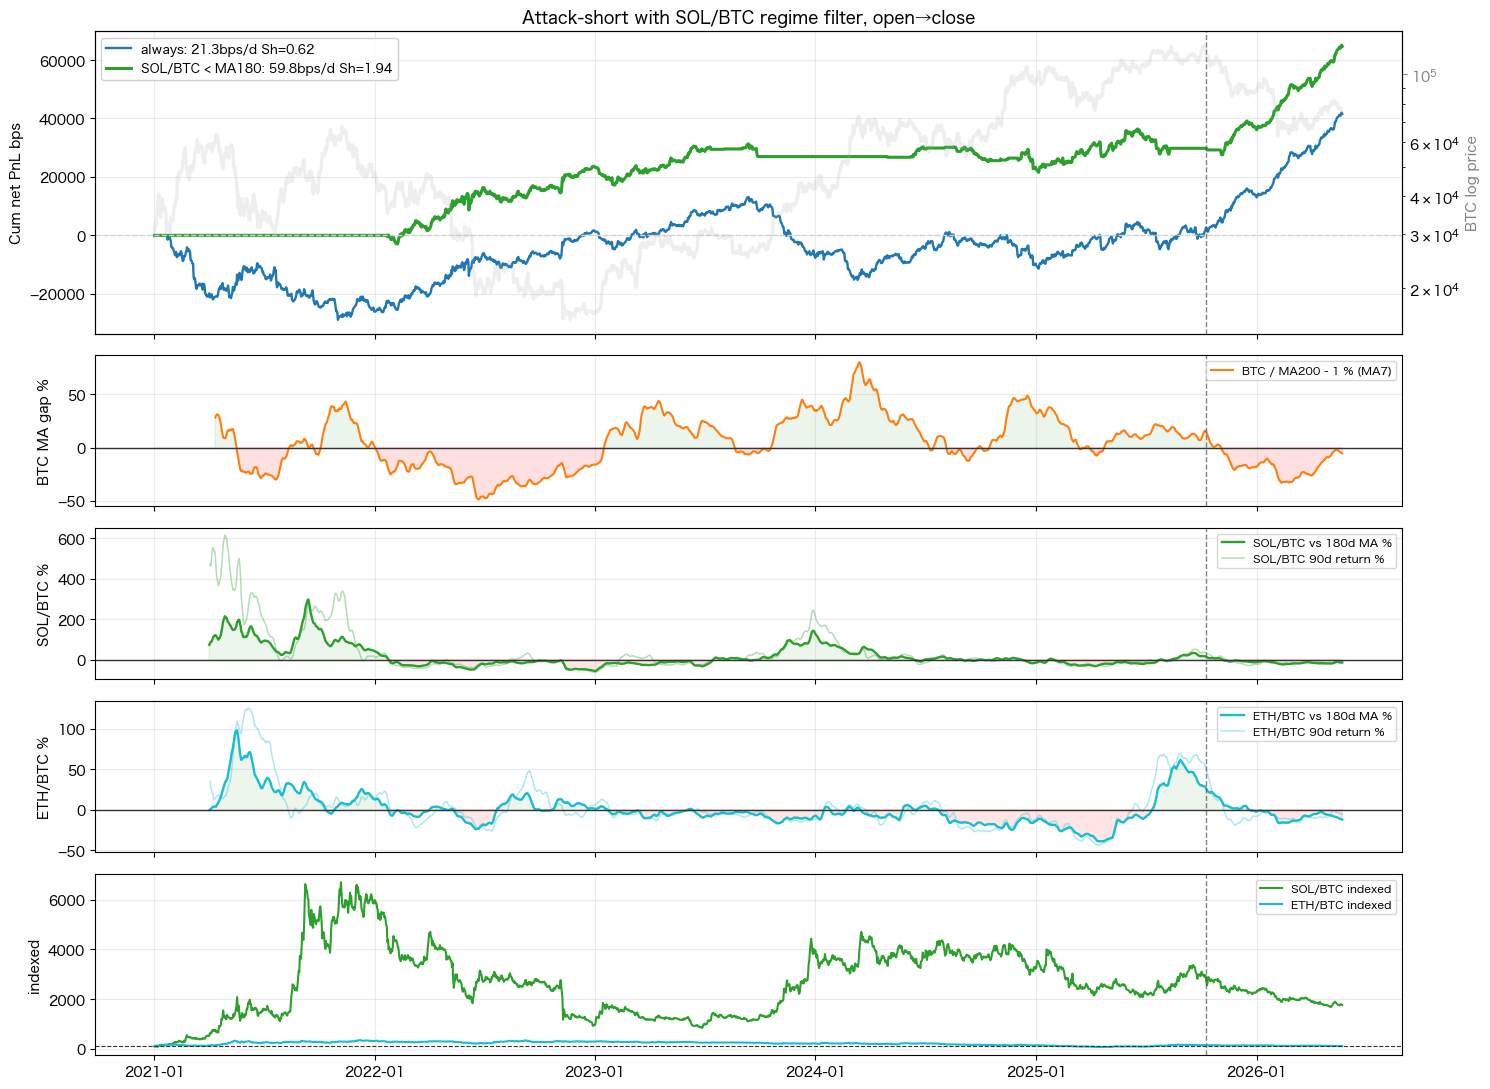

In [12]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

# --- フィルターなし vs SOL/BTCフィルター（open→close） ---
regime = pd.read_csv(DATA_DIR / "btc_eth_sol_regime_daily.csv", parse_dates=["date"])
df_always = pd.read_csv(DATA_DIR / "open_close_daily_short_top2_always.csv", parse_dates=["date"])
df_sol = pd.read_csv(DATA_DIR / "open_close_daily_short_top2_solbtc_down.csv", parse_dates=["date"])

df_always["cum"] = df_always["net_bps"].fillna(0.0).cumsum()
df_sol["cum"] = df_sol["net_bps"].fillna(0.0).cumsum()

def sharpe_val(values):
    values = values.dropna()
    if len(values) < 2 or values.std(ddof=1) == 0:
        return np.nan
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

# インデックス化（最初の非NaN値を100とする）
first_sol = regime["solbtc"].dropna().iloc[0]
first_eth = regime["ethbtc"].dropna().iloc[0]
regime["solbtc_indexed"] = regime["solbtc"] / first_sol * 100
regime["ethbtc_indexed"] = regime["ethbtc"] / first_eth * 100

# --- 描画（5パネル構成）---
fig, axes = plt.subplots(
    5, 1, figsize=(15, 11), sharex=True,
    gridspec_kw={"height_ratios": [2, 1, 1, 1, 1.2]}
)

# 上段：累積bps比較（BTC背景付き）
ax = axes[0]
ax_btc = ax.twinx()
ax_btc.plot(regime["date"], regime["BTC"], color="0.65", lw=2.4, alpha=0.18)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log price", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

always_active = df_always.loc[df_always["is_active"], "net_bps"]
sol_active = df_sol.loc[df_sol["is_active"], "net_bps"]
ax.plot(
    df_always["date"],
    df_always["cum"],
    color="#1f77b4",
    lw=1.7,
    label=f"always: {always_active.mean():.1f}bps/d Sh={sharpe_val(always_active):.2f}",
)
ax.plot(
    df_sol["date"],
    df_sol["cum"],
    color="#2ca02c",
    lw=2.2,
    label=f"SOL/BTC < MA180: {sol_active.mean():.1f}bps/d Sh={sharpe_val(sol_active):.2f}",
)
ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)
ax.set_title("Attack-short with SOL/BTC regime filter, open→close")
ax.set_ylabel("Cum net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

# BTC MA200ギャップ
ax = axes[1]
btc_gap = regime["btc_ma200_gap_ma7"] * 100
ax.plot(regime["date"], btc_gap, color="#ff7f0e", label="BTC / MA200 - 1 % (MA7)")
ax.axhline(0, color="0.2", lw=1)
ax.fill_between(regime["date"], 0, btc_gap.fillna(0),
                where=btc_gap.fillna(0) < 0, color="red", alpha=0.12)
ax.fill_between(regime["date"], 0, btc_gap.fillna(0),
                where=btc_gap.fillna(0) >= 0, color="green", alpha=0.08)
ax.set_ylabel("BTC MA gap %")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)

# SOL/BTCパネル
ax = axes[2]
sol_gap = regime["solbtc_gap_ma7"] * 100
ax.plot(regime["date"], sol_gap, color="#2ca02c", lw=1.7, label="SOL/BTC vs 180d MA %")
ax.plot(regime["date"], regime["solbtc_ret90_ma7"] * 100, color="#2ca02c",
        lw=1.1, alpha=0.35, label="SOL/BTC 90d return %")
ax.axhline(0, color="0.2", lw=1)
ax.fill_between(regime["date"], 0, sol_gap.fillna(0),
                where=sol_gap.fillna(0) < 0, color="red", alpha=0.10)
ax.fill_between(regime["date"], 0, sol_gap.fillna(0),
                where=sol_gap.fillna(0) >= 0, color="green", alpha=0.07)
ax.set_ylabel("SOL/BTC %")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)

# ETH/BTCパネル
ax = axes[3]
eth_gap = regime["ethbtc_gap_ma7"] * 100
ax.plot(regime["date"], eth_gap, color="#17becf", lw=1.7, label="ETH/BTC vs 180d MA %")
ax.plot(regime["date"], regime["ethbtc_ret90_ma7"] * 100, color="#17becf",
        lw=1.1, alpha=0.35, label="ETH/BTC 90d return %")
ax.axhline(0, color="0.2", lw=1)
ax.fill_between(regime["date"], 0, eth_gap.fillna(0),
                where=eth_gap.fillna(0) < 0, color="red", alpha=0.10)
ax.fill_between(regime["date"], 0, eth_gap.fillna(0),
                where=eth_gap.fillna(0) >= 0, color="green", alpha=0.07)
ax.set_ylabel("ETH/BTC %")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)

# インデックスパネル（SOL/BTC と ETH/BTC を期首=100で正規化）
ax = axes[4]
ax.plot(regime["date"], regime["solbtc_indexed"], color="#2ca02c", lw=1.5, label="SOL/BTC indexed")
ax.plot(regime["date"], regime["ethbtc_indexed"], color="#17becf", lw=1.5, label="ETH/BTC indexed")
ax.axhline(100, color="0.2", lw=0.8, ls="--")
ax.set_ylabel("indexed")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


---
## Step 7: コスト耐性を確認する

バックテストでよく見られる問題は、コストを甘く見積もることです。  
コストを段階的に重くしても、利益が残るかを確認します。

今回の標準コスト設定は往復8bpsです。  
（指値主体の想定。Bybit/Bitget 等で maker 手数料がゼロかマイナスの取引所を使う前提）

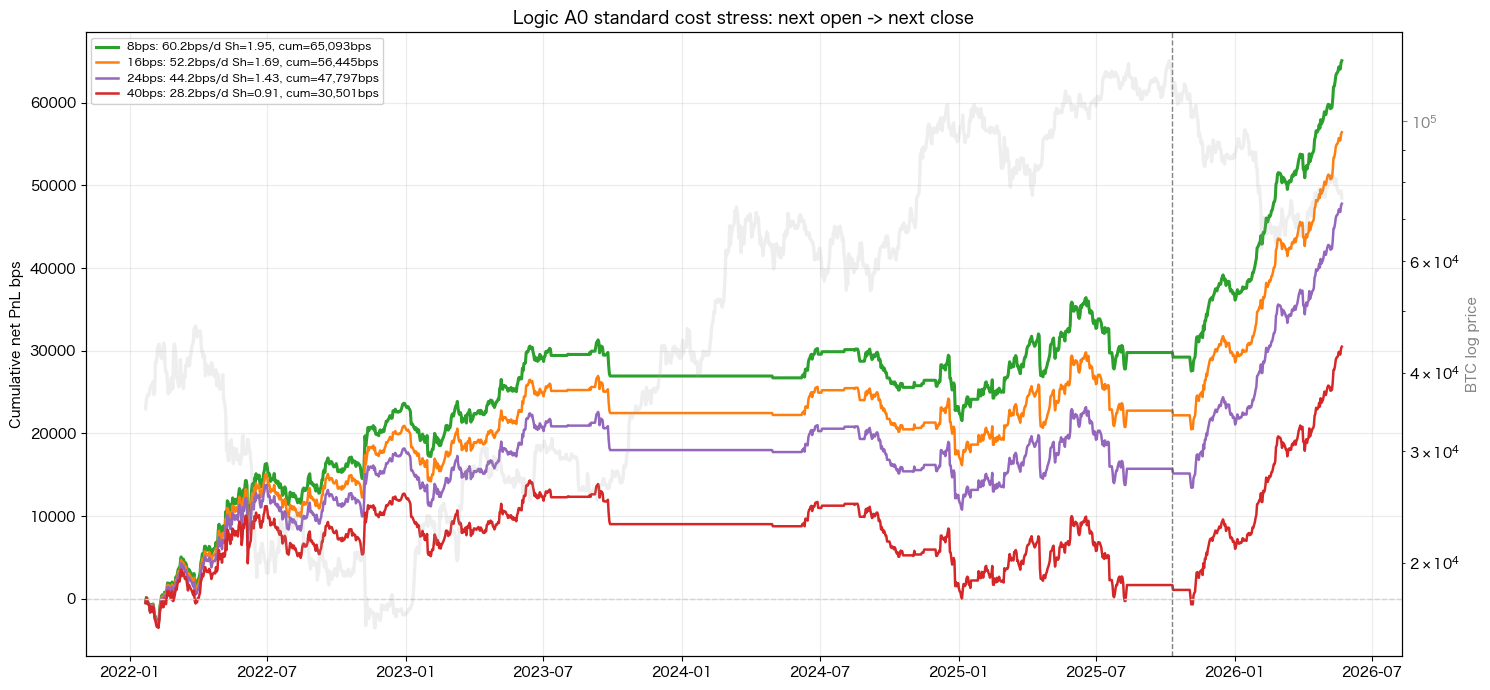

In [13]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

# --- データ読み込み ---
pos    = pd.read_csv(DATA_DIR / "positions_a0_realism.csv", parse_dates=["date"])
regime = pd.read_csv(DATA_DIR / "solbtc_regime_daily.csv",  parse_dates=["date"])

pos = pos.dropna(subset=["gross_open_close_bps"]).copy()
all_dates = pd.date_range(pos["date"].min(), pos["date"].max(), freq="D")
btc = regime.set_index("date").reindex(all_dates)["BTC"]

fee_configs = [
    ( 8, "#2ca02c", 2.2),
    (16, "#ff7f0e", 1.8),
    (24, "#9467bd", 1.8),
    (40, "#d62728", 1.8),
]

def sharpe_val(s):
    s = s.dropna()
    if len(s) < 2 or s.std(ddof=1) == 0:
        return np.nan
    return float(s.mean() / s.std(ddof=1) * np.sqrt(365))

fig, ax = plt.subplots(figsize=(15, 7))
ax_btc = ax.twinx()
ax_btc.plot(btc.index, btc, color="0.65", lw=2.4, alpha=0.18)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log price", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

for fee, color, lw in fee_configs:
    # 元スクリプトと同一：日次mean集計 → 非稼働日は0埋め → cumsum
    work = pos.copy()
    work["net"] = work["gross_open_close_bps"] - fee
    daily = (work.groupby("date", as_index=False)
             .agg(value=("net", "mean"))
             .set_index("date")
             .reindex(all_dates))
    daily.index.name = "date"
    daily["is_active"] = daily["value"].notna()
    daily["net"] = daily["value"].fillna(0.0)
    daily = daily.reset_index()
    active = daily.loc[daily["is_active"], "net"]
    cum = daily["net"].sum()
    ax.plot(daily["date"], daily["net"].cumsum(), color=color, lw=lw,
            label=f"{fee}bps: {active.mean():.1f}bps/d Sh={sharpe_val(active):.2f}, cum={cum:,.0f}bps")

ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)
ax.set_title("Logic A0 standard cost stress: next open -> next close")
ax.set_ylabel("Cumulative net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

# コスト耐性 + funding込みの比較
results = pd.DataFrame([
    {"評価条件": "close→close（研究ベースライン）",          "bps/day": 62.5, "Sharpe": 2.03, "累積bps": 67595},
    {"評価条件": "open→close  コスト 8bps  （標準）",       "bps/day": 60.2, "Sharpe": 1.95, "累積bps": 65093},
    {"評価条件": "open→close  コスト 16bps",               "bps/day": 52.2, "Sharpe": 1.69, "累積bps": 56445},
    {"評価条件": "open→close  コスト 24bps",               "bps/day": 44.2, "Sharpe": 1.43, "累積bps": 47797},
    {"評価条件": "open→close  コスト 40bps",               "bps/day": 28.2, "Sharpe": 0.91, "累積bps": 30501},
    {"評価条件": "open→close  コスト 8bps + funding込み",   "bps/day": 49.8, "Sharpe": 1.60, "累積bps": 53821},
])
results.set_index("評価条件")

,bps/day,Sharpe,累積bps
評価条件,,,
close→close（研究ベースライン）,62.5,2.03,67595
open→close コスト 8bps （標準）,60.2,1.95,65093
open→close コスト 16bps,52.2,1.69,56445
open→close コスト 24bps,44.2,1.43,47797
open→close コスト 40bps,28.2,0.91,30501
open→close コスト 8bps + funding込み,49.8,1.60,53821


### 所見

- **40bpsまで重くしてもプラスは残りました**。ただし、Sharpe 0.91 まで落ちます。
- **funding込みでも Sharpe 1.60** を維持しています。
- fundingはショートポジションにとって平均マイナス寄与です（先物割高局面ではショートがfundingを受け取れますが、全期間を通じると受け取り ＜ 支払いのケースが多い）。

### 注意

この検証では約定スリッページを完全には再現できていません。  
薄い銘柄でのスリッページはコストの見積もりを超える場合があります。

---
## Step 8: 清算イベント以降の仮説

ここは確定事実ではなく、自分の **仮説** です。

2025年10月10日〜11日に、暗号資産市場では大規模な強制清算が起きました。  
CoinGlass系の集計では、24時間で約190億ドル規模のレバレッジポジションが清算されたとされています。

このイベントで、特にアルト市場では以下が起きた可能性があります。

- レバレッジ勢が大きく退場した
- マーケットメイカーや短期勢のリスク許容度が落ちた
- アルトへの継続的な買いが弱くなった
- 先物主導の一時的なパンプが、翌日まで続きにくくなった

つまりA0が効いて見える背景は、単なる「弱い相場」ではなく、

> **10/10清算後に、アルトの前日パンプが持続しにくくなった市場構造**

かもしれません。

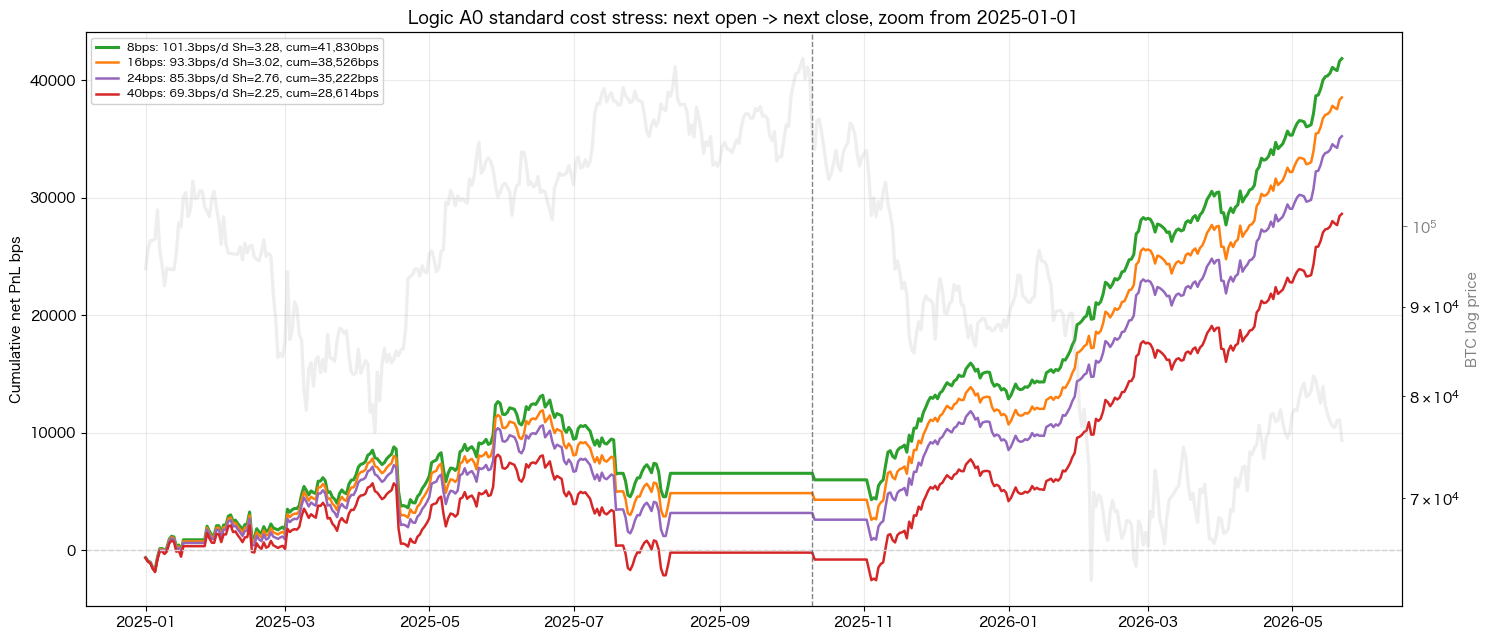

In [15]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'DejaVu Sans']

pos    = pd.read_csv(DATA_DIR / "positions_a0_realism.csv", parse_dates=["date"])
regime = pd.read_csv(DATA_DIR / "solbtc_regime_daily.csv",  parse_dates=["date"])

pos = pos.dropna(subset=["gross_open_close_bps"]).copy()
all_dates = pd.date_range(pos["date"].min(), pos["date"].max(), freq="D")
btc = regime.set_index("date").reindex(all_dates)["BTC"]
START = pd.Timestamp("2025-01-01")

fee_configs = [
    ( 8, "#2ca02c", 2.2),
    (16, "#ff7f0e", 1.8),
    (24, "#9467bd", 1.8),
    (40, "#d62728", 1.8),
]

def sharpe_val(s):
    s = s.dropna()
    if len(s) < 2 or s.std(ddof=1) == 0:
        return np.nan
    return float(s.mean() / s.std(ddof=1) * np.sqrt(365))

fig, ax = plt.subplots(figsize=(15, 6.5))
btc_plot = btc[btc.index >= START]
ax_btc = ax.twinx()
ax_btc.plot(btc_plot.index, btc_plot, color="0.65", lw=2.4, alpha=0.18)
ax_btc.set_yscale("log")
ax_btc.set_ylabel("BTC log price", color="0.5")
ax_btc.tick_params(axis="y", colors="0.5")
ax_btc.grid(False)

for fee, color, lw in fee_configs:
    work = pos.copy()
    work["net"] = work["gross_open_close_bps"] - fee
    daily = (work.groupby("date", as_index=False)
             .agg(value=("net", "mean"))
             .set_index("date")
             .reindex(all_dates))
    daily.index.name = "date"
    daily["is_active"] = daily["value"].notna()
    daily["net"] = daily["value"].fillna(0.0)
    daily = daily.reset_index()
    d25 = daily[daily["date"] >= START].copy()
    active = d25.loc[d25["is_active"], "net"]
    cum = d25["net"].sum()
    ax.plot(d25["date"], d25["net"].cumsum(), color=color, lw=lw,
            label=f"{fee}bps: {active.mean():.1f}bps/d Sh={sharpe_val(active):.2f}, cum={cum:,.0f}bps")

ax.axhline(0, color="lightgray", ls="--", lw=1)
ax.axvline(pd.Timestamp("2025-10-10"), color="0.35", ls="--", lw=1, alpha=0.75)
ax.set_title(f"Logic A0 standard cost stress: next open -> next close, zoom from {START.date()}")
ax.set_ylabel("Cumulative net PnL bps")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()


### 仮説

2025年10月10日の清算イベント後、アルト市場のレバレッジと流動性が毀損した可能性があります。

その結果、個別アルトが先物主導で一時的に過熱しても、  
現物側・継続買いのフォローが弱く、翌日にフェードしやすくなったのではないか。

| 相場の状態 | 個別アルトのパンプ | A0との相性 |
|---|---|---|
| アルト全面強気 | パンプが続きやすい | ショートは危険 |
| 10/10後のアルト冷え相場 | パンプが続きにくい | 平均回帰ショートが効きやすい可能性 |

A0は後者を狙うために、SOL/BTCフィルターを入れています。

### 注意

この仮説は **後付けの解釈** です。  
フォワードテストで実際に確認するまで、確証はありません。

参考: CoinGecko / Axios などの10/10清算イベント解説。

---
## Step 9: まとめ & 次やること

### 採用候補A0のロジック

今回の採用候補を **A0** と呼びます。名前は便宜上のラベルです。

> SOL/BTCが弱い局面だけ、  
> 先物乖離demeanと前日先物リターンが高い銘柄を上位2つショートする。

### 仕様

```text
basis       = (future_close - spot_close) / spot_close
demean_21d  = basis[t] - mean(basis[t-21:t-1])    ← 当日を含まない過去21日平均
ret1        = future_close[t] / future_close[t-1] - 1
score       = 0.70 × demean_rank + 0.30 × ret1_rank

対象銘柄 : 現物USDT + USDT無期限先物が両方ある銘柄
方向     : score上位2銘柄をショート
条件     : SOL/BTC < SOL/BTC 180日MA の時だけ
判定     : 毎日09:00 JST（日足確定後）
約定     : signal t close → entry t+1 open → exit t+1 close
コスト   : 往復8bpsを標準
```

### スコアの意味

| 特徴量 | 重み | 意味 |
|---|---:|---|
| demean_rank | 70% | 普段より先物が過熱している銘柄を優先 |
| ret1_rank | 30% | 前日に先物価格が上がった銘柄を優先 |

このウェイトは、demeanを主軸にした出発点として設定しています。  
比率の感度検証は今後の課題として残しています。

---

### わかったこと

- A0は、冷え相場で先物主導パンプが続かない時に機能しそう
- `demean` だけより、前日先物リターン `ret1` を混ぜた方が改善した
- ret1確認つきscoreは、ロングよりショート側の方が筋が良さそうだった
- SOL/BTCが弱い局面に絞ると、パンプ後のフェードを取りやすくなった
- 10/10清算イベント以降、アルトパンプが持続しにくい相場になった可能性がある

---

### フォワードテストの方針

- 毎日09:00 JSTにシグナル（上位2銘柄）を記録する
- entry open と exit close を実測で記録する
- funding・スリッページ・約定遅延を別で管理する

---

### ほへと先生に見てもらいたい点

1. basis計算がこの定義で妥当か（index price ではなく spot close を使っている）
2. SOL/BTCをアルトレジームフィルターにする発想は適切か
3. ret1を30%混ぜる比率は妥当か、どう感度検証すべきか
4. 10/10清算イベント後の構造変化という解釈は妥当か
5. フォワードテストで特に見るべき実運用コストは何か

---
## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。